# Constrained Optimization in JAXCad

Constraints and gradient-based optimization address complementary aspects of a design problem: constraints define a feasible region, the optimizer finds the best design within it.

This notebook combines both: a distance constraint pins a sphere's center to a 2D manifold, and gradient descent with explicit projection finds the point on that manifold closest to a target.

In [8]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcad.constraints import DistanceConstraint
from jaxcad.geometry import Vector
from jaxcad.render import render_marching_cubes
from jaxcad.sdf import Sphere, Translate

## Scene and constraint

The sphere's center `p` is free but constrained to remain at distance 2 from the origin. The target lies inside the constraint sphere - not on the manifold - so the optimal solution is the point on the sphere surface closest to the target.

In [9]:
anchor = Vector(jnp.array([0.0, 0.0, 0.0]), free=False, name="anchor")
p = Vector(jnp.array([2.0, 0.0, 0.0]), free=True, name="p")

DistanceConstraint(p, anchor, 2.0)

scene = Translate(Sphere(radius=0.3), offset=p)
target = jnp.array([1.0, 1.5, 0.0])

## Optimizing on the constraint manifold

Each step takes a gradient descent step in the ambient space, then projects back onto the constraint manifold (the sphere of radius 2). The projection is analytic for a distance constraint: `p <- 2 * p / ||p||`.

In [10]:
def obj(q):
    return jnp.sum((q - target) ** 2)


lr = 0.15
p_current = jnp.array([2.0, 0.0, 0.0])
trajectory = [p_current]

for step in range(60):
    value, grad = jax.value_and_grad(obj)(p_current)
    p_new = p_current - lr * grad
    p_current = 2.0 * p_new / jnp.linalg.norm(p_new)  # project onto sphere
    trajectory.append(p_current)
    if step % 15 == 0:
        print(f"step {step:3d}  loss={value:.4f}  ||p||={jnp.linalg.norm(p_current):.4f}")

step   0  loss=3.2500  ||p||=2.0000
step  15  loss=0.0391  ||p||=2.0000
step  30  loss=0.0389  ||p||=2.0000
step  45  loss=0.0389  ||p||=2.0000


In [11]:
optimized = p_current
print(f"Optimized center:     {optimized}")
print(f"Distance from anchor: {jnp.linalg.norm(optimized):.6f}  (should be 2.0)")
print(f"Distance from target: {jnp.linalg.norm(optimized - target):.6f}")

# Analytic optimum: closest point on sphere to target
p_star = 2.0 * target / jnp.linalg.norm(target)
print(f"Analytic optimum:     {p_star}")

Optimized center:     [1.1094005 1.6641004 0.       ]
Distance from anchor: 2.000000  (should be 2.0)
Distance from target: 0.197224
Analytic optimum:     [1.1094004 1.6641006 0.       ]


## Trajectory

The trajectory stays on the circle (constraint manifold projected to the XY plane) and converges to the closest point to the target.

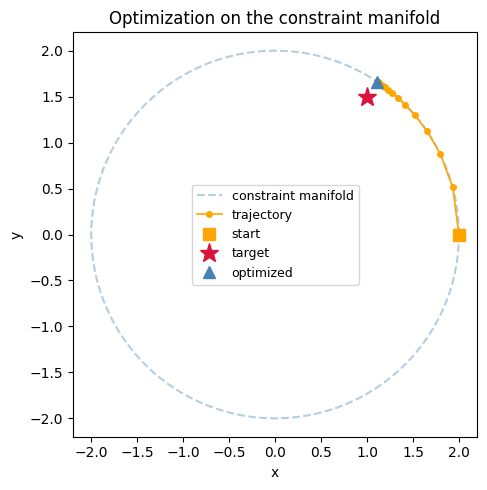

In [12]:
traj = np.array(trajectory)

theta = np.linspace(0, 2 * np.pi, 200)
cx, cy = 2 * np.cos(theta), 2 * np.sin(theta)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(cx, cy, "--", color="steelblue", alpha=0.4, label="constraint manifold")
ax.plot(
    traj[:, 0], traj[:, 1], "o-", color="orange", markersize=4, linewidth=1.2, label="trajectory"
)
ax.plot(*traj[0, :2], "s", color="orange", markersize=9, zorder=5, label="start")
ax.plot(*target[:2], "*", color="crimson", markersize=14, zorder=6, label="target")
ax.plot(*traj[-1, :2], "^", color="steelblue", markersize=9, zorder=5, label="optimized")
ax.set_aspect("equal")
ax.legend(fontsize=9)
ax.set_title("Optimization on the constraint manifold")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Render before and after

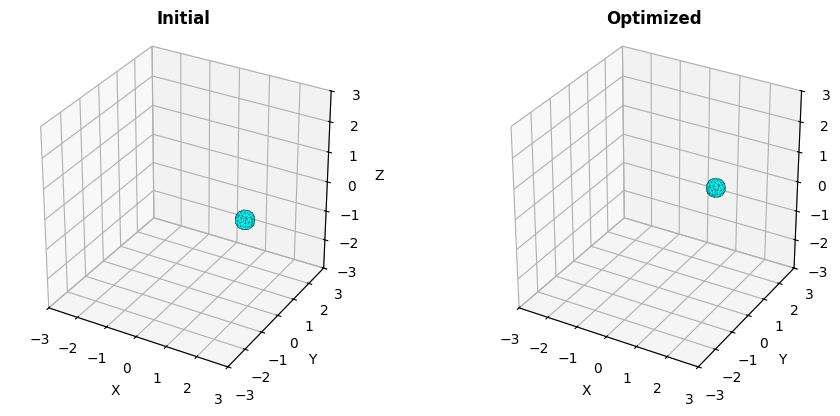

In [13]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(121, projection="3d")
render_marching_cubes(Translate(Sphere(radius=0.3), offset=traj[0]), ax=ax1, title="Initial")

ax2 = fig.add_subplot(122, projection="3d")
render_marching_cubes(Translate(Sphere(radius=0.3), offset=optimized), ax=ax2, title="Optimized")

plt.tight_layout()
plt.show()

## Summary

The workflow:

1. **Attach constraints** - `DistanceConstraint` defines the feasible manifold.
2. **Gradient step** in the ambient space using `jax.grad`.
3. **Project** back onto the manifold after each step - for a sphere constraint the projection is `p <- r * p / ||p||`.

This pattern generalizes: any differentiable constraint has an associated projection or retraction that can be composed with gradient descent to stay feasible throughout optimization.